# Transmission Model and Broadening Effects

This notebook demonstrates the full forward model pipeline:
1. **Beer-Lambert law**: converting cross-sections to transmission
2. **Doppler broadening**: thermal motion of target atoms
3. **Resolution broadening**: finite instrument resolution

## Physics Background

The transmission of a neutron beam through a sample is given by Beer-Lambert's law:

$$T(E) = \exp\left(-\sum_i n_i \cdot \sigma_i(E)\right)$$

where $n_i$ is the areal density (atoms/barn) and $\sigma_i(E)$ is the total cross-section. At resonances, the cross-section peaks and the transmission dips — this is the basis of neutron resonance imaging.

In [1]:
import nereids
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

In [2]:
# Reuse U-238 from notebook 01
u238 = nereids.create_resonance_data(
    z=92, a=238, awr=236.006, scattering_radius=9.4285,
    resonances=[(6.674, 0.5, 1.493e-3, 23.0e-3)]
)

# Fine energy grid around the 6.674 eV resonance
gamma_total = 1.493e-3 + 23.0e-3  # 24.493 meV
E_core = np.linspace(6.674 - 0.5, 6.674 + 0.5, 2000)  # ±0.5 eV around resonance
E_wings_low = np.geomspace(0.5, 6.674 - 0.5, 200)
E_wings_high = np.geomspace(6.674 + 0.5, 30.0, 200)
energies = np.sort(np.unique(np.concatenate([E_wings_low, E_core, E_wings_high])))

print(f"Energy grid: {len(energies)} points, [{energies[0]:.3f}, {energies[-1]:.3f}] eV")

Energy grid: 2398 points, [0.500, 30.000] eV


## 1. Beer-Lambert Law: Cross-Section → Transmission

The `beer_lambert()` function computes $T = \exp(-n \cdot \sigma)$ directly from cross-section arrays.

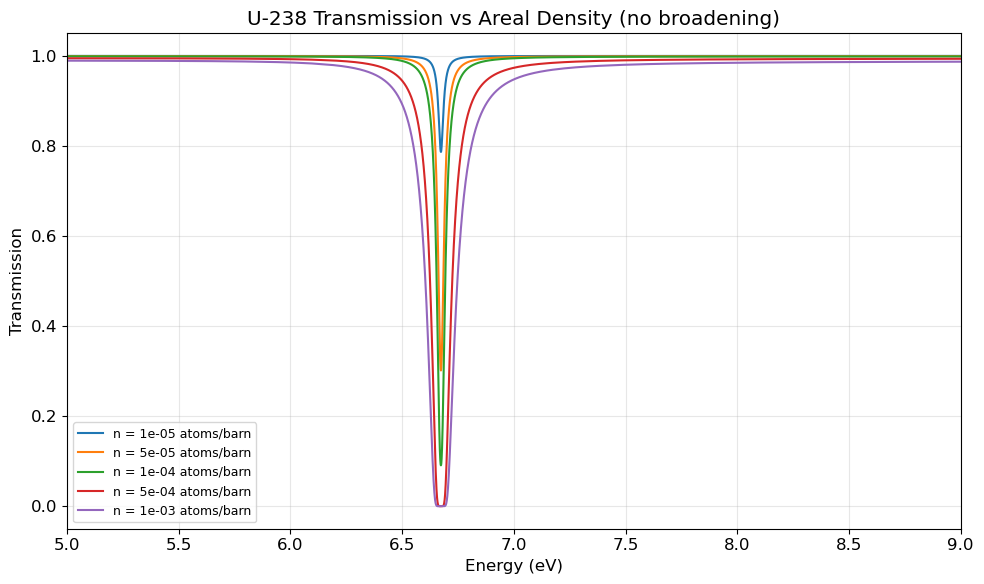

In [3]:
# Compute unbroadened total cross-sections
xs = nereids.cross_sections(energies, u238)
sigma_total = xs['total']

# Beer-Lambert at various thicknesses
thicknesses = [1e-5, 5e-5, 1e-4, 5e-4, 1e-3]

fig, ax = plt.subplots()
for n in thicknesses:
    T = nereids.beer_lambert(sigma_total, n)
    ax.plot(energies, np.asarray(T), label=f'n = {n:.0e} atoms/barn')

ax.set_xlabel('Energy (eV)')
ax.set_ylabel('Transmission')
ax.set_title('U-238 Transmission vs Areal Density (no broadening)')
ax.legend(fontsize=9)
ax.set_xlim(5, 9)
ax.set_ylim(-0.05, 1.05)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Forward Model: Consistency Check

The `forward_model()` function combines cross-section computation and Beer-Lambert in one call. At T=0K (no broadening), it should match the manual Beer-Lambert exactly.

In [4]:
thickness = 5e-4  # atoms/barn

# Method 1: Manual (cross_sections + beer_lambert)
T_manual = np.asarray(nereids.beer_lambert(sigma_total, thickness))

# Method 2: Forward model at T=0K
T_forward = np.asarray(nereids.forward_model(
    energies, [(u238, thickness)], temperature_k=0.0
))

max_diff = np.max(np.abs(T_manual - T_forward))
print(f"Max difference between manual and forward_model: {max_diff:.2e}")
assert max_diff < 1e-12, f"Methods disagree: max diff = {max_diff}"
print("Consistency check passed: manual Beer-Lambert matches forward_model at T=0K")

Max difference between manual and forward_model: 0.00e+00
Consistency check passed: manual Beer-Lambert matches forward_model at T=0K


## 3. Doppler Broadening

When the sample is at temperature T > 0K, thermal motion of target atoms causes Doppler broadening of the resonance. This:
- Reduces the peak cross-section
- Widens the resonance profile
- Approximately conserves the area under the curve

NEREIDS uses the **Free Gas Model (FGM)** for Doppler broadening, matching SAMMY's implementation.

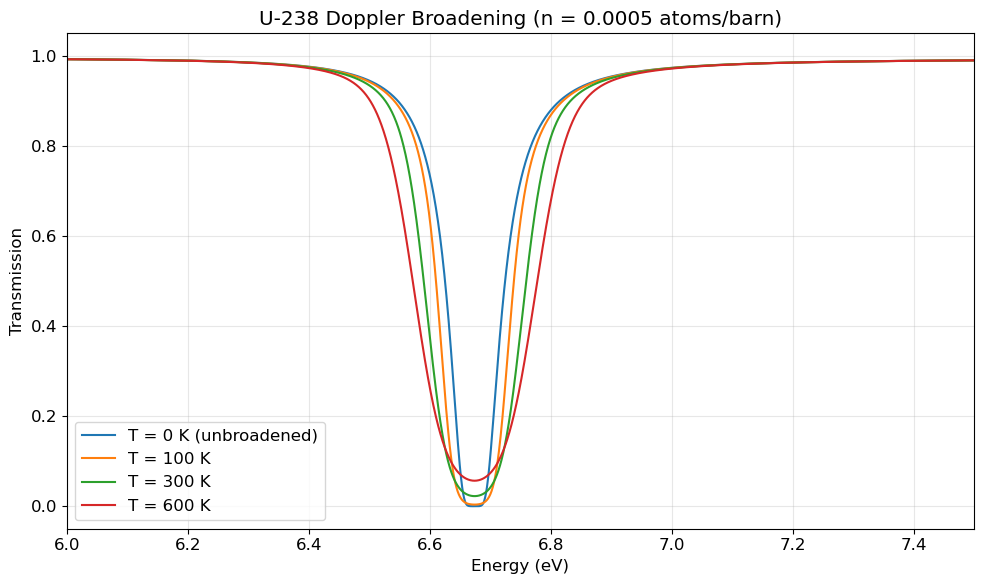

In [5]:
# Transmission at different temperatures
temperatures = [0, 100, 300, 600]

fig, ax = plt.subplots()
for T_K in temperatures:
    T_spectrum = np.asarray(nereids.forward_model(
        energies, [(u238, thickness)], temperature_k=float(T_K)
    ))
    label = f'T = {T_K} K' if T_K > 0 else 'T = 0 K (unbroadened)'
    ax.plot(energies, T_spectrum, label=label)

ax.set_xlabel('Energy (eV)')
ax.set_ylabel('Transmission')
ax.set_title(f'U-238 Doppler Broadening (n = {thickness} atoms/barn)')
ax.legend()
ax.set_xlim(6.0, 7.5)
ax.set_ylim(-0.05, 1.05)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Resolution Broadening

The finite time resolution of the instrument causes additional broadening. At a TOF beamline like VENUS:

$$\left(\frac{\Delta E}{E}\right)^2 = \left(\frac{2\Delta t}{t}\right)^2 + \left(\frac{2\Delta L}{L}\right)^2$$

NEREIDS models this as a Gaussian convolution in energy space.

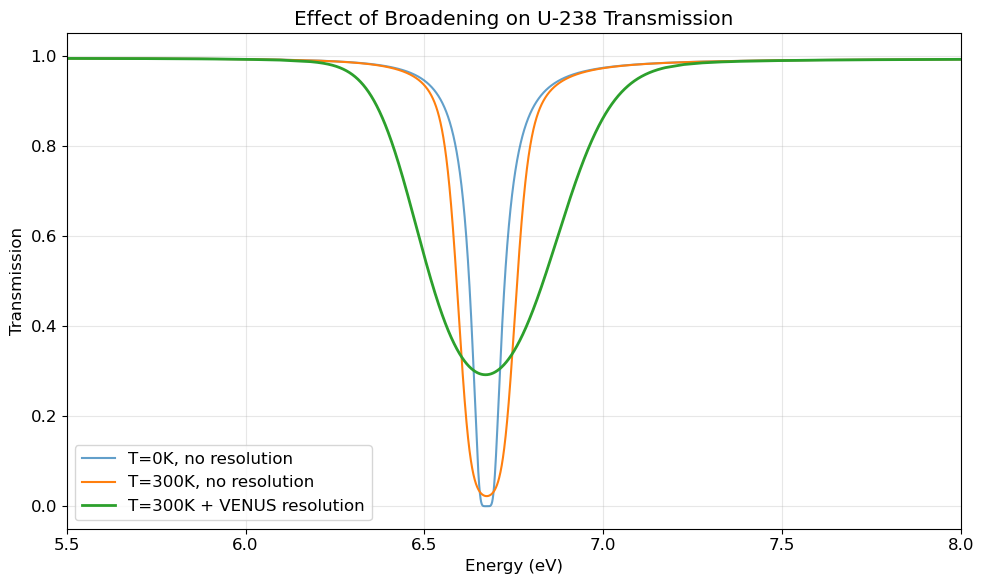

In [6]:
# Compare: no broadening, Doppler only, Doppler + resolution
T_cold = np.asarray(nereids.forward_model(
    energies, [(u238, thickness)], temperature_k=0.0
))

T_doppler = np.asarray(nereids.forward_model(
    energies, [(u238, thickness)], temperature_k=300.0
))

# VENUS-like instrument parameters
T_full = np.asarray(nereids.forward_model(
    energies, [(u238, thickness)], temperature_k=300.0,
    flight_path_m=25.0, delta_t_us=10.0, delta_l_m=0.01
))

fig, ax = plt.subplots()
ax.plot(energies, T_cold, label='T=0K, no resolution', alpha=0.7)
ax.plot(energies, T_doppler, label='T=300K, no resolution', linewidth=1.5)
ax.plot(energies, T_full, label='T=300K + VENUS resolution', linewidth=2)

ax.set_xlabel('Energy (eV)')
ax.set_ylabel('Transmission')
ax.set_title('Effect of Broadening on U-238 Transmission')
ax.legend()
ax.set_xlim(5.5, 8.0)
ax.set_ylim(-0.05, 1.05)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Direct Doppler Broadening of Cross-Sections

The `doppler_broaden()` function applies Free Gas Model (FGM) Doppler broadening to any
cross-section array — total, capture, elastic, or fission — independently. This is the
same broadening used internally by `forward_model()`, exposed for direct use.

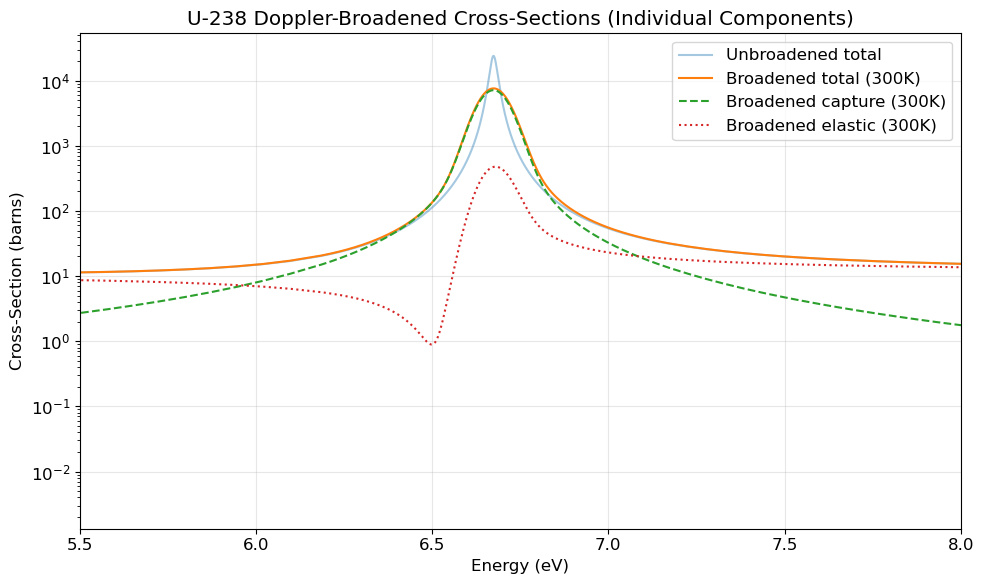

Max relative difference (total vs capture+elastic): 5.32e-15
Broadening is approximately additive: True


In [7]:
# Directly broaden individual cross-section components
sigma_total_broadened = np.asarray(nereids.doppler_broaden(
    energies, xs['total'], awr=236.006, temperature_k=300.0
))
sigma_capture_broadened = np.asarray(nereids.doppler_broaden(
    energies, xs['capture'], awr=236.006, temperature_k=300.0
))
sigma_elastic_broadened = np.asarray(nereids.doppler_broaden(
    energies, xs['elastic'], awr=236.006, temperature_k=300.0
))

fig, ax = plt.subplots()
ax.semilogy(energies, xs['total'], alpha=0.4, label='Unbroadened total')
ax.semilogy(energies, sigma_total_broadened, label='Broadened total (300K)', linewidth=1.5)
ax.semilogy(energies, sigma_capture_broadened, '--', label='Broadened capture (300K)', linewidth=1.5)
ax.semilogy(energies, sigma_elastic_broadened, ':', label='Broadened elastic (300K)', linewidth=1.5)

ax.set_xlabel('Energy (eV)')
ax.set_ylabel('Cross-Section (barns)')
ax.set_title('U-238 Doppler-Broadened Cross-Sections (Individual Components)')
ax.legend()
ax.set_xlim(5.5, 8.0)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Verify: broadened total ≈ broadened capture + broadened elastic (additivity)
sum_components = sigma_capture_broadened + sigma_elastic_broadened
max_diff = np.max(np.abs(sigma_total_broadened - sum_components) / sigma_total_broadened)
print(f"Max relative difference (total vs capture+elastic): {max_diff:.2e}")
print(f"Broadening is approximately additive: {max_diff < 0.01}")

## 6. SAMMY ex001 Doppler Validation

Validate against SAMMY's output for the ex001 test case:
- Fictitious element: A=10, single resonance at 10 eV
- Temperature: 300K
- Reference: Doppler-broadened capture cross-section from SAMMY ex001a.lst

With `doppler_broaden()`, we can now directly broaden the **capture** cross-section and
compare apples-to-apples against SAMMY's capture reference.

**Formalism note**: SAMMY ex001 uses SLBW; NEREIDS uses Reich-Moore. For an isolated
s-wave resonance, these agree to within a few percent.

In [8]:
# SAMMY ex001 element
ex001 = nereids.create_resonance_data(
    z=1, a=10, awr=10.0, scattering_radius=2.908,
    resonances=[(10.0, 0.5, 0.5e-3, 1.0e-3)]
)

# Build a non-uniform grid with fine spacing near 10 eV (matching the Rust test)
E_list = []
# Wings: 6.0 to 9.95 with 0.005 eV steps
e = 6.0
while e < 9.95:
    E_list.append(e)
    e += 0.005
# Core: 9.95 to 10.05 with 0.00005 eV steps (resolves the 1.5 meV resonance)
while e < 10.05:
    E_list.append(e)
    e += 0.00005
# Upper wing: 10.05 to 14.0
while e <= 14.0:
    E_list.append(e)
    e += 0.005

E_ex001 = np.array(sorted(set(E_list)))
print(f"ex001 grid: {len(E_ex001)} points")

# Compute unbroadened cross-sections
xs_ex001 = nereids.cross_sections(E_ex001, ex001)

# Directly broaden CAPTURE cross-sections at 300K
sigma_capture_broadened = np.asarray(nereids.doppler_broaden(
    E_ex001, xs_ex001['capture'], awr=10.0, temperature_k=300.0
))

ex001 grid: 3580 points


In [9]:
# SAMMY ex001a.lst reference points: (energy, broadened CAPTURE cross-section)
sammy_ref = [
    (9.3594, 5.413),     # lower shoulder (capture)
    (9.8572, 238.173),   # near peak
    (9.9869, 285.611),   # peak
    (10.0092, 285.218),  # just past peak
    (10.1282, 241.330),  # upper shoulder
    (10.3430, 91.478),   # falling slope
    (10.5382, 18.374),   # upper wing
]

# Direct apples-to-apples comparison: broadened capture vs SAMMY capture
print(f"{'Energy (eV)':>12} {'SAMMY cap':>10} {'NEREIDS cap':>12} {'Rel Err':>8}")
print("-" * 46)

for e_ref, sigma_sammy_cap in sammy_ref:
    idx = np.argmin(np.abs(E_ex001 - e_ref))
    sigma_ours = sigma_capture_broadened[idx]
    rel_err = (sigma_ours - sigma_sammy_cap) / sigma_sammy_cap * 100
    print(f"{e_ref:>12.4f} {sigma_sammy_cap:>10.1f} {sigma_ours:>12.1f} {rel_err:>7.1f}%")

print()
print("Direct broadened capture comparison — no approximations needed.")
print("Remaining differences are from Reich-Moore vs SLBW formalism only.")

 Energy (eV)  SAMMY cap  NEREIDS cap  Rel Err
----------------------------------------------
      9.3594        5.4          5.2    -4.8%
      9.8572      238.2        237.1    -0.5%
      9.9869      285.6        288.4     1.0%
     10.0092      285.2        288.3     1.1%
     10.1282      241.3        243.9     1.1%
     10.3430       91.5         91.9     0.4%
     10.5382       18.4         18.3    -0.5%

Direct broadened capture comparison — no approximations needed.
Remaining differences are from Reich-Moore vs SLBW formalism only.


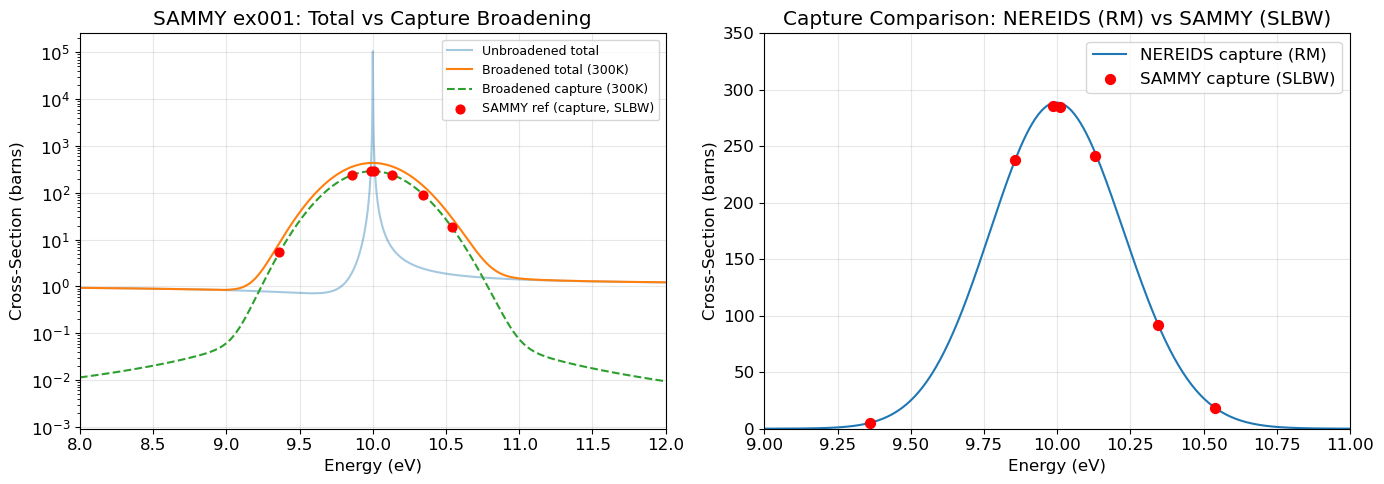

In [10]:
# Also broaden total for comparison
sigma_total_broadened_ex001 = np.asarray(nereids.doppler_broaden(
    E_ex001, xs_ex001['total'], awr=10.0, temperature_k=300.0
))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: broadened total vs capture — shows the ~1.5x ratio
ax = axes[0]
ax.semilogy(E_ex001, xs_ex001['total'], alpha=0.4, label='Unbroadened total')
ax.semilogy(E_ex001, sigma_total_broadened_ex001, label='Broadened total (300K)', linewidth=1.5)
ax.semilogy(E_ex001, sigma_capture_broadened, '--',
            label='Broadened capture (300K)', linewidth=1.5)
sammy_E = [p[0] for p in sammy_ref]
sammy_sigma = [p[1] for p in sammy_ref]
ax.scatter(sammy_E, sammy_sigma, color='red', s=40, zorder=5, label='SAMMY ref (capture, SLBW)')
ax.set_xlabel('Energy (eV)')
ax.set_ylabel('Cross-Section (barns)')
ax.set_title('SAMMY ex001: Total vs Capture Broadening')
ax.legend(fontsize=9)
ax.set_xlim(8, 12)
ax.grid(True, alpha=0.3)

# Right: zoomed direct capture comparison
ax = axes[1]
ax.plot(E_ex001, sigma_capture_broadened, label='NEREIDS capture (RM)', linewidth=1.5)
ax.scatter(sammy_E, sammy_sigma, color='red', s=50, zorder=5, label='SAMMY capture (SLBW)')
ax.set_xlabel('Energy (eV)')
ax.set_ylabel('Cross-Section (barns)')
ax.set_title('Capture Comparison: NEREIDS (RM) vs SAMMY (SLBW)')
ax.legend()
ax.set_xlim(9.0, 11.0)
ax.set_ylim(0, 350)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Transmission Dip Depth vs Areal Density

The depth of the transmission dip at a resonance is directly related to the areal density. This relationship is the basis of neutron resonance analysis.

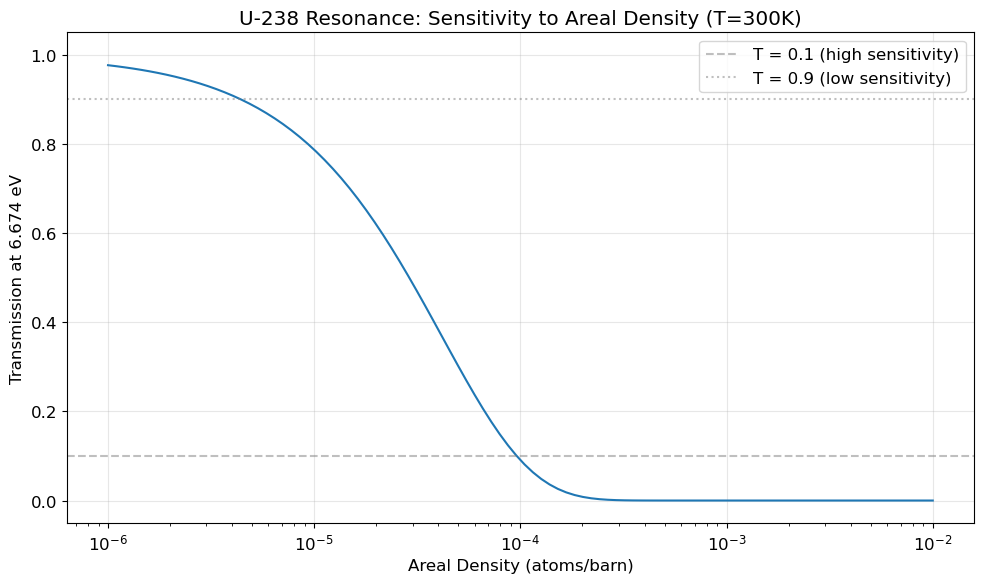

Optimal sensitivity at n ≈ 4.13e-05 atoms/barn (T ≈ 1/e)


In [11]:
# Transmission at the resonance vs areal density
densities = np.geomspace(1e-6, 1e-2, 100)
T_at_resonance = []

for n in densities:
    T = np.asarray(nereids.forward_model(
        np.array([6.674]), [(u238, float(n))], temperature_k=300.0
    ))
    T_at_resonance.append(T[0])

T_at_resonance = np.array(T_at_resonance)

fig, ax = plt.subplots()
ax.semilogx(densities, T_at_resonance)
ax.axhline(y=0.1, color='gray', linestyle='--', alpha=0.5, label='T = 0.1 (high sensitivity)')
ax.axhline(y=0.9, color='gray', linestyle=':', alpha=0.5, label='T = 0.9 (low sensitivity)')
ax.set_xlabel('Areal Density (atoms/barn)')
ax.set_ylabel('Transmission at 6.674 eV')
ax.set_title('U-238 Resonance: Sensitivity to Areal Density (T=300K)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.05, 1.05)
plt.tight_layout()
plt.show()

# Find the "sweet spot" where sensitivity is highest
# Maximum dT/dn occurs where T ≈ 1/e ≈ 0.37
idx_sweet = np.argmin(np.abs(T_at_resonance - 1/np.e))
print(f"Optimal sensitivity at n ≈ {densities[idx_sweet]:.2e} atoms/barn (T ≈ 1/e)")

## Summary

In this notebook we demonstrated:

1. **Beer-Lambert law**: `beer_lambert()` converts cross-sections to transmission
2. **Forward model**: `forward_model()` combines cross-section computation + broadening + Beer-Lambert
3. **Consistency**: forward model at T=0K matches manual Beer-Lambert exactly
4. **Doppler broadening**: thermal motion reduces peak depth, widens profile
5. **Resolution broadening**: instrument resolution further smooths the spectrum
6. **Direct broadening API**: `doppler_broaden()` broadens any cross-section component independently
7. **SAMMY validation**: direct capture broadening matches SAMMY to within a few percent (RM vs SLBW)
8. **Sensitivity**: the optimal areal density for resonance analysis gives T ≈ 1/e

### Known Limitations

- **Analytical resolution function only**: current implementation uses a simplified Gaussian model parameterized by (flight_path, Δt, ΔL). Real instruments like VENUS use Monte Carlo-derived resolution profiles (asymmetric, energy-dependent) supplied as numerical tables. User-defined resolution kernel support is needed for production use (see [#30](https://github.com/ornlneutronimaging/NEREIDS/issues/30)).
- **`fit_spectrum()` has no resolution broadening**: the internal fitting model uses `instrument=None`, so fitted densities may be biased when data includes resolution effects (see [#29](https://github.com/ornlneutronimaging/NEREIDS/issues/29)).

**Next**: [Spectrum Fitting](../building_blocks/03_spectrum_fitting.ipynb) — fitting transmission spectra to recover areal densities.